Global Yield_mean  max=4.304  min=1.719
  Saved: C:/data/fig_11/Soybean-BioCro/climate_normal\climate_normal_grain_yield_mean_with_years.csv
Districts: 28  |  Grid pts: 3695


C:\Users\yaron\AppData\Local\Temp\ipykernel_27436\1644104726.py:212: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


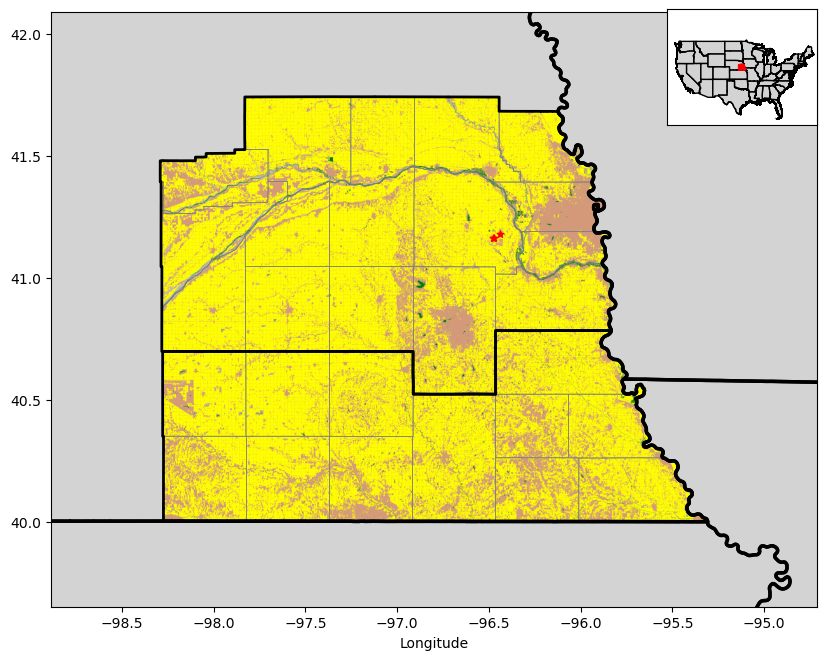

In [27]:
# =====================================================================
# FIG 1 — Modeled Soybean Yield Map (2002-2006)
# Single-panel land-use map with modeled yield overlay,
# district boundaries, county/state borders, and locator inset.
# =====================================================================

# ── 1. Imports ──────────────────────────────────────────────
import os
import glob
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import show
from matplotlib.colors import ListedColormap, BoundaryNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ── 2. Data Paths ──────────────────────────────────────────
_nb_dir  = os.path.dirname(os.path.abspath('__file__'))
DATA_DIR = os.path.normpath(os.path.join(_nb_dir, '..', 'data'))

PATHS = {
    'us_states':     os.path.join(DATA_DIR, 'us_states_for_map.geojson'),
    'counties_usa':  os.path.join(DATA_DIR, 'counties_usa_for_map.geojson'),
    'temp_shp':      os.path.join(DATA_DIR, 'COMBINED_DIST.geojson'),
    'combined_dist': os.path.join(DATA_DIR, 'COMBINED_DIST_with_county .geojson'),
    'grid':          os.path.join(DATA_DIR, '4km_2025_grid_point_with_no_city.geojson'),
    'ag_60':         os.path.join(DATA_DIR, 'ag_dis_s.geojson'),
    'ag_90':         os.path.join(DATA_DIR, 'ag_dis_n.geojson'),
    'point_loc':     'C:/Users/yaron/Desktop/FIG_REDY/combined_geojson_data1.geojson',
    'raster':        'C:/Users/yaron/Downloads/cropLandcover30m_wg84_clip.tif',
}

BIOCRO_DIR  = 'C:/data/fig_11/Soybean-BioCro/climate_normal'
MIN_MAX_DIR = 'C:/data/fig_11/min_max'

# ── 3. CDL Raster Colormap ─────────────────────────────────
CDL_COLORS = {1: "#FFFF00", 5: "#008000", 122: "#D49A7A", 'other': "#BEBEBE"}
cdl_cmap   = ListedColormap([CDL_COLORS[1], CDL_COLORS[5],
                              CDL_COLORS[122], CDL_COLORS['other']])
cdl_bounds = [0, 1.5, 5.5, 122.5, 200]
cdl_norm   = BoundaryNorm(cdl_bounds, len(cdl_cmap.colors))

# ── 4. Plot Styling ────────────────────────────────────────
STYLE = {
    'cmap_yield':    'YlGn',
    'lw_districts':  0.5,
    'lw_states':     2.5,
    'lw_counties':   0.5,
    'lw_boundary':   2.0,
    'color_borders': 'black',
    'color_counties':'gray',
    'facecolor_bg':  'lightgray',
    'zoom_main':     0.20,
    'zoom_inset':    10,
    'vmin':          2.9,
    'vmax':          4.2,
}

# ── 5. Helper Functions ────────────────────────────────────
def set_zoom(ax, gdf, padding):
    """Set axis limits from GeoDataFrame bounds + fractional padding."""
    xmin, ymin, xmax, ymax = gdf.total_bounds
    dx = (xmax - xmin) * padding
    dy = (ymax - ymin) * padding
    ax.set_xlim(xmin - dx, xmax + dx)
    ax.set_ylim(ymin - dy, ymax + dy)


def add_inset(parent_ax, ref_gdf, states_gdf, zoom_pad):
    """Add a small locator inset map to the upper-right of *parent_ax*."""
    axins = inset_axes(parent_ax, width=1.5, height=1.5, loc='upper right',
                       borderpad=0, bbox_to_anchor=(1.00, 1.033),
                       bbox_transform=parent_ax.transAxes)
    xmin, ymin, xmax, ymax = ref_gdf.total_bounds
    xp = (xmax - xmin) * zoom_pad
    yp = (ymax - ymin) * zoom_pad
    axins.set_xlim(xmin - xp, xmax + xp)
    axins.set_ylim(ymin - yp, ymax + yp)
    states_gdf.to_crs(epsg=4326).plot(ax=axins, color='lightgray',
                                       edgecolor='black', alpha=1.0)
    ref_gdf.plot(ax=axins, color='lightgray', edgecolor='red', alpha=1.0)
    axins.set_xticks([]); axins.set_yticks([]); axins.set_title('')
    return axins


def process_yield_data(input_directory):
    """Read per-year CSVs, merge on real_id, compute Yield_mean."""
    dir_name = os.path.basename(os.path.normpath(input_directory))
    output_file = os.path.join(input_directory,
                               f'{dir_name}_grain_yield_mean_with_years.csv')
    if os.path.exists(output_file):
        os.remove(output_file)

    csvs = glob.glob(os.path.join(input_directory, '*.csv'))
    if not csvs:
        print(f'  [!] No CSVs in {input_directory}')
        return None

    frames = []
    for fp in csvs:
        try:
            df = pd.read_csv(fp)
            if 'real_id' not in df.columns:
                if 'grid_id' in df.columns:
                    df.rename(columns={'grid_id': 'real_id'}, inplace=True)
                elif 'id' in df.columns:
                    df.rename(columns={'id': 'real_id'}, inplace=True)
                else:
                    continue
            ycol = ('Grain' if 'Grain' in df.columns else
                    'yield' if 'yield' in df.columns else None)
            if ycol is None:
                continue
            suffix = os.path.splitext(os.path.basename(fp))[0]
            df = df[['real_id', ycol]].rename(columns={ycol: f'{ycol}_{suffix}'})
            frames.append(df)
        except Exception as e:
            print(f'  [!] Error reading {fp}: {e}')

    if not frames:
        return None

    merged = frames[0]
    for f in frames[1:]:
        merged = pd.merge(merged, f, on='real_id', how='outer')

    ycols = [c for c in merged.columns
             if c.startswith('Grain_') or c.startswith('yield_')]
    merged['Yield_mean'] = merged[ycols].mean(axis=1)
    merged.to_csv(output_file, index=False)
    print(f'  Saved: {output_file}')
    return output_file


def get_global_max_min(directory, column_name):
    """Get global max/min for a column across all CSVs in a directory."""
    g_min, g_max = float('inf'), float('-inf')
    for fn in os.listdir(directory):
        if not fn.endswith('.csv'):
            continue
        df = pd.read_csv(os.path.join(directory, fn))
        if column_name in df.columns:
            g_min = min(g_min, df[column_name].min())
            g_max = max(g_max, df[column_name].max())
    return g_max, g_min


# ── 6. Load Data ───────────────────────────────────────────
g_max, g_min = get_global_max_min(MIN_MAX_DIR, 'Yield_mean')
print(f'Global Yield_mean  max={g_max:.3f}  min={g_min:.3f}')

csv_biocro = process_yield_data(BIOCRO_DIR)
grain_mean_BioCro = pd.read_csv(csv_biocro)

us_states          = gpd.read_file(PATHS['us_states']).to_crs(epsg=4326)
counties_usa       = gpd.read_file(PATHS['counties_usa']).to_crs(epsg=4326)
temp_shp           = gpd.read_file(PATHS['temp_shp']).to_crs(epsg=4326)
combined_districts = gpd.read_file(PATHS['combined_dist']).set_crs(epsg=4326)
grid_file          = gpd.read_file(PATHS['grid']).set_crs(epsg=4326)
point_loc          = gpd.read_file(PATHS['point_loc'])

grid_file['Id'] = grid_file['ORIG_FID']

# ── 7. Merge Yield into Districts ──────────────────────────
combined_districts_3857 = combined_districts.to_crs(epsg=3857)
grid_file_3857          = grid_file.to_crs(epsg=3857)

merged_gdf = grid_file_3857.merge(grain_mean_BioCro, left_on='Id', right_on='real_id')
gdf_joined = gpd.sjoin(merged_gdf, combined_districts_3857,
                        how='inner', predicate='within')

mean_values = gdf_joined.groupby('index_right')['Yield_mean'].mean()
combined_districts['mean_grain_yield_B'] = mean_values

print(f'Districts: {len(combined_districts)}  |  Grid pts: {len(grid_file)}')

# ── 8. Plot ────────────────────────────────────────────────
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 8))

ax2.set_visible(False)
ax3.set_visible(False)

with rasterio.open(PATHS['raster']) as src:
    show(src, ax=ax1, cmap=cdl_cmap)

counties_usa.plot(ax=ax1, facecolor='none', edgecolor=STYLE['color_borders'],
                  linewidth=STYLE['lw_counties'], zorder=5)

combined_districts.plot(
    ax=ax1, column='mean_grain_yield_B', cmap=STYLE['cmap_yield'],
    legend=False, edgecolor=STYLE['color_counties'], facecolor='none',
    linewidth=STYLE['lw_districts'],
    vmin=STYLE['vmin'], vmax=STYLE['vmax'], zorder=3)

temp_shp.plot(ax=ax1, facecolor='none', edgecolor='black',
              linewidth=STYLE['lw_boundary'], zorder=15)

us_states.plot(ax=ax1, facecolor='none', edgecolor=STYLE['color_borders'],
               linewidth=STYLE['lw_states'], zorder=29)

point_loc.plot(ax=ax1, color='red', markersize=25, zorder=99, marker='*')

ax1.set_facecolor(STYLE['facecolor_bg'])
ax1.set_xlabel('Longitude')
ax1.set_ylabel('')
set_zoom(ax1, combined_districts, STYLE['zoom_main'])

add_inset(ax1, combined_districts, us_states, STYLE['zoom_inset'])

plt.tight_layout()
plt.show()